## 📌 Introduction

In this project, an end-to-end data pipeline is developed for preprocessing, transforming, and loading data using Python. The objective is to automate the ETL (Extract, Transform, Load) process and prepare raw data for machine learning applications.

The Titanic dataset is used as a real-world example to demonstrate data cleaning, feature engineering, and pipeline creation using pandas and scikit-learn. The final output includes a processed dataset and a reusable pipeline that can be applied to new data.



In [ ]:
# TASK 1: DATA PIPELINE (Titanic Dataset)

# Import required libraries
import pandas as pd
import numpy as np

# Scikit-learn tools for preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# -------------------------------
# 1. EXTRACT (Load the dataset)
# -------------------------------
data = pd.read_csv("/content/Titanic-Dataset.csv")

# Display first few rows
print("Original Data:")
print(data.head())


# -------------------------------
# 2. TRANSFORM (Data Cleaning & Processing)
# -------------------------------

# Drop unnecessary columns (not useful for analysis/model)
data = data.drop(['Name', 'Ticket', 'Cabin'], axis=1)

# Separate features (X) and target (y)
X = data.drop('Survived', axis=1)
y = data['Survived']

# Define numerical and categorical columns
num_cols = ['Age', 'Fare']
cat_cols = ['Sex', 'Embarked', 'Pclass']

# -------------------------------
# Numerical Pipeline
# -------------------------------
# Step 1: Fill missing values with mean
# Step 2: Scale values for uniformity
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# -------------------------------
# Categorical Pipeline
# -------------------------------
# Step 1: Fill missing values with most frequent value
# Step 2: Convert categories into numerical format
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder())
])

# -------------------------------
# Combine both pipelines
# -------------------------------
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# Apply preprocessing
X_processed = preprocessor.fit_transform(X)

# Show processed data shape
print("Processed Data Shape:", X_processed.shape)


# -------------------------------
# 3. LOAD (Save processed data)
# -------------------------------

# Convert processed data to DataFrame
processed_data = pd.DataFrame(
    X_processed.toarray() if hasattr(X_processed, "toarray") else X_processed
)

# Save to CSV file
processed_data.to_csv("processed_titanic.csv", index=False)

print("Pipeline completed successfully!")

Original Data:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   Na

In [ ]:
import pandas as pd

data = pd.read_csv("/content/Titanic-Dataset.csv")
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 📊 Data Visualization

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


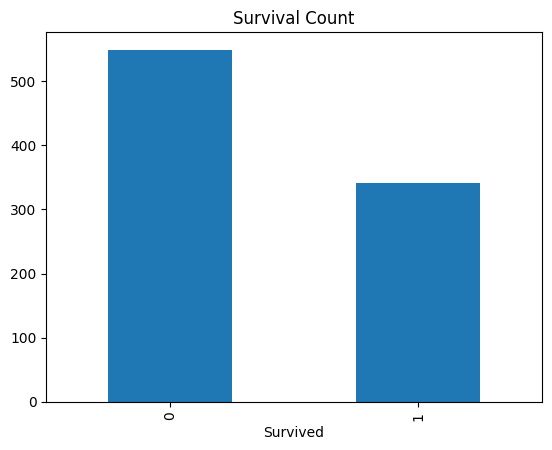

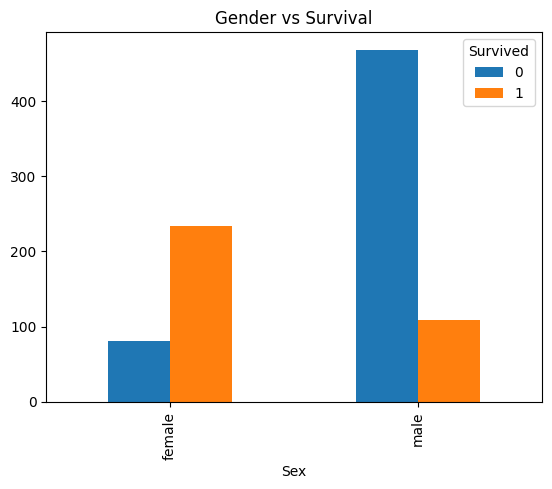

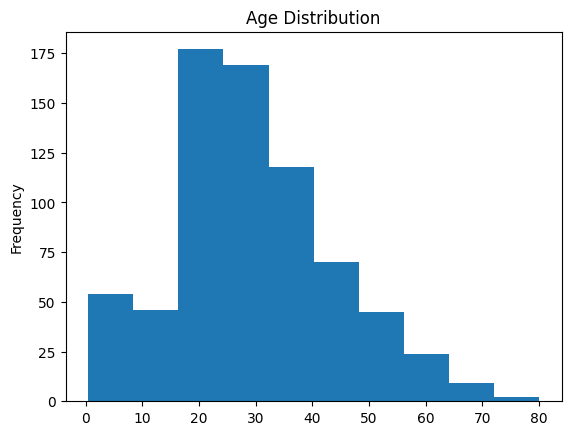

Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64
Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
dtype: int64
AgeGroup  Survived
Child     0            29
          1            40
Teen      0            68
          1            42
Adult     0           232
          1           153
Mid-age   0            78
          1            50
Senior    0            17
          1             5
dtype: int64


/tmp/ipykernel_5503/751461860.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(data.groupby(['AgeGroup', 'Survived']).size())


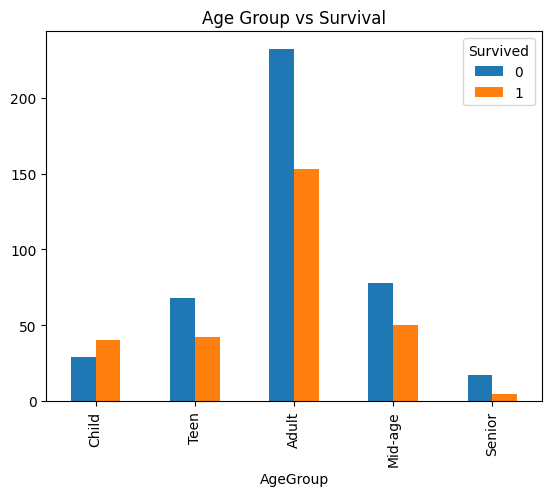

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
data = pd.read_csv("/content/Titanic-Dataset.csv")

# Check missing values
print(data.isnull().sum())

# -------------------------------
# Basic Visualizations
# -------------------------------

# Survival count
data['Survived'].value_counts().plot(kind='bar')
plt.title("Survival Count")
plt.show()

# Gender vs Survival
pd.crosstab(data['Sex'], data['Survived']).plot(kind='bar')
plt.title("Gender vs Survival")
plt.show()

# Age distribution
data['Age'].plot(kind='hist')
plt.title("Age Distribution")
plt.show()

# -------------------------------
# GroupBy Analysis
# -------------------------------

# Avg age by survival
print(data.groupby('Survived')['Age'].mean())

# Survival count by gender
print(data.groupby(['Sex', 'Survived']).size())

# -------------------------------
# Age Group Analysis
# -------------------------------

# Create age groups
bins = [0, 12, 20, 40, 60, 80]
labels = ['Child', 'Teen', 'Adult', 'Mid-age', 'Senior']

data['AgeGroup'] = pd.cut(data['Age'], bins=bins, labels=labels)

# Survival by age group
print(data.groupby(['AgeGroup', 'Survived']).size())

# Plot age group survival
pd.crosstab(data['AgeGroup'], data['Survived']).plot(kind='bar')
plt.title("Age Group vs Survival")
plt.show()

Feature Engineering


In [ ]:
# Create Family Size
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1

# Create IsAlone feature
data['IsAlone'] = (data['FamilySize'] == 1).astype(int)

# Drop less useful columns
data = data.drop(['Name', 'Ticket', 'Cabin'], axis=1)

data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,AgeGroup,FamilySize,IsAlone
0,1,0,3,male,22.0,1,0,7.2500,S,Adult,2,0
1,2,1,1,female,38.0,1,0,71.2833,C,Adult,2,0
2,3,1,3,female,26.0,0,0,7.9250,S,Adult,1,1
3,4,1,1,female,35.0,1,0,53.1000,S,Adult,2,0
4,5,0,3,male,35.0,0,0,8.0500,S,Adult,1,1


In [ ]:
# Survival by Family Size
print(data.groupby('FamilySize')['Survived'].mean())

# Survival by IsAlone
print(data.groupby('IsAlone')['Survived'].mean())

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64
IsAlone
0    0.505650
1    0.303538
Name: Survived, dtype: float64


Data Preprocessing Pipeline

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Features
X = data.drop('Survived', axis=1)
y = data['Survived']

num_cols = ['Age', 'Fare', 'FamilySize']
cat_cols = ['Sex', 'Embarked', 'Pclass', 'IsAlone']

# Pipelines
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder())
])

# Combine
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

X_processed = preprocessor.fit_transform(X)

print("New Processed Shape:", X_processed.shape)

New Processed Shape: (891, 13)


In [ ]:
import joblib

# Save fitted pipeline
joblib.dump(preprocessor, "titanic_pipeline.pkl")

print("Pipeline saved successfully!")

Pipeline saved successfully!


In [ ]:
# Load pipeline
loaded_pipeline = joblib.load("titanic_pipeline.pkl")

# Test it
X_test_processed = loaded_pipeline.transform(X)

print("Loaded pipeline working. Shape:", X_test_processed.shape)

Loaded pipeline working. Shape: (891, 13)


Saving Pipeline & Data

In [ ]:
import pandas as pd

processed_df = pd.DataFrame(
    X_processed.toarray() if hasattr(X_processed, "toarray") else X_processed
)

processed_df.to_csv("processed_titanic.csv", index=False)

print("Processed dataset saved!")

Processed dataset saved!


# ==============================
# MODEL BUILDING & EVALUATION
# ==============================

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
preds = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

Accuracy: 0.7988826815642458
              precision    recall  f1-score   support

           0       0.81      0.87      0.83       105
           1       0.79      0.70      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [ ]:
from sklearn.pipeline import Pipeline

full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

full_pipeline.fit(X, y)

print("Full pipeline trained!")

Full pipeline trained!


In [ ]:
feature_names = full_pipeline.named_steps['preprocessor'].get_feature_names_out()
coeffs = full_pipeline.named_steps['model'].coef_[0]

for name, val in zip(feature_names, coeffs):
    print(name, val)

num__Age -0.4730796761780064
num__Fare 0.1163339811965478
num__FamilySize -0.6014443146502441
cat__Sex_female 1.3471594535993978
cat__Sex_male -1.2518379599571583
cat__Embarked_C 0.148910105105875
cat__Embarked_Q 0.16824252640900775
cat__Embarked_S -0.22183113787264452
cat__Pclass_1 0.9685313042776036
cat__Pclass_2 0.12302006551483559
cat__Pclass_3 -0.9962298761501994
cat__IsAlone_0 0.38551646317748867
cat__IsAlone_1 -0.29019496953524926


In [ ]:
import joblib
joblib.dump(full_pipeline, "titanic_full_pipeline.pkl")

['titanic_full_pipeline.pkl']

## 🚀 Conclusion

This project successfully implemented a complete ETL (Extract, Transform, Load) data pipeline using Python. The pipeline efficiently handled missing values, encoded categorical variables, and scaled numerical features using scikit-learn, making the dataset ready for machine learning applications.

Feature engineering techniques such as creating FamilySize and IsAlone improved the quality of the data and provided deeper insights into passenger survival patterns. The pipeline was further extended to include a machine learning model, demonstrating its practical usability in predictive tasks.

Overall, the project highlights the importance of structured data preprocessing and showcases how automated pipelines can simplify real-world data science workflows.
